# 04 - TS-ICL and covariates

TS-ICL is the leading method in this benchmark under artificial-gap
validation. This notebook has two parts:

- **Part A -- the real TS-ICL calling API**: the actual calling convention
  used throughout this repository (`src/coastal_gap_reconstruction/tsicl_helpers.py`),
  for target-only and covariate-conditioned inputs. Runs live only if
  `tsicl`/`torch` are installed in the current environment; otherwise it
  degrades gracefully and prints a clear skip message.
- **Part B -- the full benchmark comparison**: loads the precomputed public
  benchmark tables (no model re-runs) and shows how TS-ICL compares against
  every other method in this repository, by gap length, season, and event
  status, plus which covariates actually help (the covariate-mechanism
  ranking).

For the full, always-executable, visual, multi-configuration comparison
(target-only vs. +satellite chlorophyll vs. +wind/SST, on a real 14-day
gap, plotted against withheld ground truth), see
`demo/gap_reconstruction_walkthrough.ipynb` and run `bash demo/run_demo.sh`.

## Part A.1 Installing TS-ICL

TS-ICL is a separately-locked, optional environment
(`environments/tsicl/`) -- not part of this repository's standard
`uv sync` environment, so installing or running it never destabilizes the
core package:

```bash
cd environments/tsicl && uv sync --locked && cd ../..
```

On first use it downloads its public, non-gated pretrained checkpoint
(~209 MB, Hugging Face repository `taharnbl/TS-ICL`, revision
`f01f3869a735694691401cd67a5e19c17e94e220`, filename `tsicl-v1.ckpt`,
SHA-256 `a67ae9f694c2a83cfc8e7ec41745ff4f41a4a76ee2b17172ec3430d8d29da431`
-- pinned and hash-verified by
`coastal_gap_reconstruction.tsicl_helpers.verify_checkpoint_provenance`)
and caches it locally. It is released under the **TS-ICL Non-Commercial
License v1.0, (c) EDF SA 2026** -- separate from this repository's own
license, and prohibits commercial/production use -- review it yourself
before use. This repository does not vendor TS-ICL;
`src/coastal_gap_reconstruction/tsicl_helpers.py` is the single
authoritative calling layer (this notebook, the demo, and
`experiments/chlorophyll/run_tsicl_benchmark.py`/
`run_tsicl_covariate_analysis.py` all call the same functions). Full
provenance, exact commands, and reproduction-tolerance evidence:
`docs/reproducibility.md`.

In [1]:
import sys

import numpy as np
import pandas as pd

sys.path.insert(0, "../src")

from coastal_gap_reconstruction.data_loading import load_daily_target, load_feature_table
from coastal_gap_reconstruction.tsicl_helpers import (
    impute_masked_series,
    load_tsicl,
    log10_to_physical,
)

target_df = load_daily_target("../data/chlorophyll/chlorophyll_daily_target.csv")
features_df = load_feature_table("../data/chlorophyll/chlorophyll_predictor_features_curated.csv")

# TS-ICL operates in log10 space, as used throughout this benchmark.
log10_chl = np.log10(target_df["chl_mean"].clip(lower=1e-3))

## Part A.2 Loading the model

`load_tsicl()` never raises: it returns `(None, status)` with
`status.live = False` if `tsicl`/`torch` are not installed or the
checkpoint cannot be fetched, so this notebook degrades gracefully instead
of failing outright.

In [2]:
model, status = load_tsicl()
print(status)

if not status.live:
    print(
        "TS-ICL is not available in this environment "
        "(cd environments/tsicl && uv sync --locked, or run demo/run_demo.sh "
        "for the same environment set up automatically). The remaining live "
        "cells are skipped."
    )

TSICLStatus(live=False, device='unknown', load_time_s=0.0002911090850830078, error="ModuleNotFoundError: No module named 'torch'")
TS-ICL is not available in this environment (cd environments/tsicl && uv sync --locked, or run demo/run_demo.sh for the same environment set up automatically). The remaining live cells are skipped.


## Part A.3 Target-only imputation

Tensor shapes: `inputs` is a 1D float32 tensor of length T with `NaN`
marking the positions to reconstruct; `covars`, when supplied, is
`(1, T, C)` -- batch dimension first, one series. `model.impute(...)`
returns a mean prediction and a set of quantile predictions, both length
T, already denormalized back to log10-chlorophyll space.

In [3]:
if status.live:
    example_start, example_end = "2018-03-01", "2018-03-14"
    window = log10_chl.loc["2018-02-20":"2018-03-20"].copy()
    masked = window.copy()
    masked.loc[example_start:example_end] = np.nan

    mean, quantiles = impute_masked_series(model, masked.to_numpy(), covariate_array=None)

    result = pd.DataFrame(
        {
            "date": window.index,
            "pred_chl": log10_to_physical(mean),
            "q05": log10_to_physical(quantiles[:, 0]),
            "q95": log10_to_physical(quantiles[:, -1]),
        }
    )
    result.loc[result["date"].between(example_start, example_end)]

## Part A.4 Covariate-conditioned imputation

Same call, with a satellite chlorophyll proxy passed as a single covariate
channel. `build_covariate_block` in `tsicl_helpers.py` documents the one
non-obvious shape requirement (an explicit batch dimension of size 1).

In [4]:
if status.live:
    from coastal_gap_reconstruction.tsicl_helpers import build_covariate_block

    satellite_proxy = features_df["chl_cons_log10"].loc["2018-02-20":"2018-03-20"]
    covar_block = build_covariate_block(satellite_proxy.to_numpy()[:, None])[0]  # (T, C) for impute_masked_series

    mean_cov, quantiles_cov = impute_masked_series(model, masked.to_numpy(), covariate_array=covar_block)

    result_cov = pd.DataFrame(
        {
            "date": window.index,
            "pred_chl": log10_to_physical(mean_cov),
            "q05": log10_to_physical(quantiles_cov[:, 0]),
            "q95": log10_to_physical(quantiles_cov[:, -1]),
        }
    )
    result_cov.loc[result_cov["date"].between(example_start, example_end)]

## Part A.5 Notes

- Evaluate TS-ICL outputs only at positions that were actually masked in a
  proper artificial-gap validation run (notebook 02) -- the single window
  above is illustrative of the API only, not a validation result.
- Never treat a prediction on a real (naturally occurring) gap as
  validation evidence -- see `docs/evidence_and_limitations.md`.
- Both benchmark drivers use `load_tsicl_strict()`, which verifies the
  checkpoint hash/revision and raises immediately on any mismatch, rather
  than this notebook's lenient `load_tsicl()`, which degrades gracefully
  when TS-ICL isn't installed.

---

## Part B.1 The full benchmark comparison

Loads the precomputed public benchmark tables and produces comparison
tables/plots. Fully executable on the public data included in this
repository (no model re-runs required).

In [5]:
summary = pd.read_csv("../results/chlorophyll/chlorophyll_benchmark_summary.csv")
scores = pd.read_csv("../results/chlorophyll/chlorophyll_artificial_gap_scores.csv")
summary

,method_family,method_public_name,compared_against_public_name,stratum,n_gaps,n_bootstrap_replicates,metric,method_value,comparison_value,delta,ci_lo,ci_hi,interpretation,evidence_tier
0,foundation_model_zero_shot,TS-ICL (satellite chlorophyll proxy covariate),Linear interpolation baseline,all_gaps,680,2000,day_weighted_mae,0.2432,0.2706,-0.0274,-0.0359,-0.0185,significant_improvement,"validation-grade (artificial-gap pool, n=680-681)"
1,foundation_model_zero_shot,TS-ICL (satellite chlorophyll proxy covariate),Gaussian process (time-only),all_gaps,681,2000,day_weighted_mae,0.2432,0.2628,-0.0196,-0.0257,-0.0139,significant_improvement,"validation-grade (artificial-gap pool, n=680-681)"
2,foundation_model_zero_shot,TS-ICL (satellite chlorophyll proxy covariate),Engineered hybrid pipeline (validation-aware m...,all_gaps,681,2000,day_weighted_mae,0.2432,0.2601,-0.0169,-0.0244,-0.0101,significant_improvement,"validation-grade (artificial-gap pool, n=680-681)"
3,foundation_model_zero_shot,TS-ICL (satellite chlorophyll proxy covariate),"TS-ICL (target-only, no covariates)",all_gaps,681,2000,day_weighted_mae,0.2432,0.2505,-0.0073,-0.0098,-0.0048,significant_improvement,"validation-grade (artificial-gap pool, n=680-681)"
4,foundation_model_zero_shot,TS-ICL (wind/upwelling forcing covariate),"TS-ICL (target-only, no covariates)",all_gaps,681,2000,day_weighted_mae,0.2477,0.2505,-0.0028,-0.0067,0.0011,directional_not_significant,"validation-grade (artificial-gap pool, n=681)"
5,foundation_model_zero_shot,TS-ICL (curated physical-forcing covariate set),"TS-ICL (target-only, no covariates)",all_gaps,681,2000,day_weighted_mae,0.2469,0.2505,-0.0036,-0.0063,-0.0010,significant_improvement,"validation-grade (artificial-gap pool, n=681)"
6,foundation_model_zero_shot,TS-ICL (wind/upwelling forcing covariate),Linear interpolation baseline,all_gaps,680,2000,day_weighted_mae,0.2477,0.2706,-0.0229,-0.0321,-0.0137,significant_improvement,"validation-grade (artificial-gap pool, n=681)"
7,foundation_model_zero_shot,TS-ICL (curated physical-forcing covariate set),Linear interpolation baseline,all_gaps,680,2000,day_weighted_mae,0.2469,0.2706,-0.0237,-0.0329,-0.0145,significant_improvement,"validation-grade (artificial-gap pool, n=681)"
8,foundation_model_zero_shot,TS-ICL (ocean current/transport covariate),"TS-ICL (target-only, no covariates)",all_gaps,681,2000,day_weighted_mae,0.2617,0.2505,0.0112,0.0077,0.0150,significant_degradation,"validation-grade (artificial-gap pool, n=681)"
9,baseline,Monthly climatology baseline,Linear interpolation baseline,all_gaps,680,2000,day_weighted_mae,0.3515,0.2706,0.0809,0.0654,0.0971,significant_degradation,validation-grade baseline


## Part B.2 Overall comparison: TS-ICL satellite-proxy vs. other methods

**Support**: `chlorophyll_benchmark_summary.csv` is on the **full 681-gap
pool** (n_gaps reported as 680-681 depending on which gaps a given
comparator has a prediction for). For a direct comparison against the
classical/probabilistic/gap-edge methods in notebook 03
(`experiments/chlorophyll/benchmark_contract.py`), use the **matched
449-gap support** instead
(`results/chlorophyll/chlorophyll_matched_support_method_metrics.csv`,
`method_id` in `{tsicl_target_only, tsicl_satellite_proxy}`) -- it is the
only support every one of those methods and TS-ICL both have a released
row on.

In [6]:
summary[["method_public_name", "compared_against_public_name", "delta", "ci_lo", "ci_hi", "interpretation"]]

,method_public_name,compared_against_public_name,delta,ci_lo,ci_hi,interpretation
0,TS-ICL (satellite chlorophyll proxy covariate),Linear interpolation baseline,-0.0274,-0.0359,-0.0185,significant_improvement
1,TS-ICL (satellite chlorophyll proxy covariate),Gaussian process (time-only),-0.0196,-0.0257,-0.0139,significant_improvement
2,TS-ICL (satellite chlorophyll proxy covariate),Engineered hybrid pipeline (validation-aware m...,-0.0169,-0.0244,-0.0101,significant_improvement
3,TS-ICL (satellite chlorophyll proxy covariate),"TS-ICL (target-only, no covariates)",-0.0073,-0.0098,-0.0048,significant_improvement
4,TS-ICL (wind/upwelling forcing covariate),"TS-ICL (target-only, no covariates)",-0.0028,-0.0067,0.0011,directional_not_significant
5,TS-ICL (curated physical-forcing covariate set),"TS-ICL (target-only, no covariates)",-0.0036,-0.0063,-0.0010,significant_improvement
6,TS-ICL (wind/upwelling forcing covariate),Linear interpolation baseline,-0.0229,-0.0321,-0.0137,significant_improvement
7,TS-ICL (curated physical-forcing covariate set),Linear interpolation baseline,-0.0237,-0.0329,-0.0145,significant_improvement
8,TS-ICL (ocean current/transport covariate),"TS-ICL (target-only, no covariates)",0.0112,0.0077,0.0150,significant_degradation
9,Monthly climatology baseline,Linear interpolation baseline,0.0809,0.0654,0.0971,significant_degradation


## Part B.3 Performance by gap length

In [7]:
by_length = scores[scores["stratum_type"] == "gap_length"]
pivot_length = by_length.pivot_table(index="stratum_value", columns="method_public_name", values="day_weighted_mae")
pivot_length

method_public_name,Engineered hybrid pipeline (validation-aware method assignment),Gaussian process (time-only),Linear interpolation baseline,Monthly climatology baseline,TS-ICL (curated physical-forcing covariate set),TS-ICL (ocean current/transport covariate),TS-ICL (satellite chlorophyll proxy covariate),"TS-ICL (target-only, no covariates)",TS-ICL (wind/upwelling forcing covariate)
stratum_value,,,,,,,,,
L=1,0.1037,0.1037,0.1077,0.3720,0.10365,0.1344,0.10595,0.1060,0.1102
L=10,0.2233,0.2273,0.2252,0.3458,0.21330,0.2224,0.20880,0.2134,0.2094
L=14,0.2523,0.2481,0.2535,0.3445,0.23430,0.2489,0.23450,0.2385,0.2301
L=21,0.2754,0.2755,0.2747,0.3488,0.25650,0.2785,0.25310,0.2607,0.2583
L=3,0.1290,0.1290,0.1329,0.3657,0.12260,0.1311,0.12220,0.1231,0.1202
L=30,0.2651,0.2660,0.2779,0.3541,0.25430,0.2710,0.25420,0.2594,0.2566
L=45,0.3173,0.3065,0.3578,0.3652,0.30030,0.3108,0.29230,0.3030,0.3062
L=60,0.2938,0.3190,0.3094,0.3459,0.28360,0.2980,0.27660,0.2906,0.2874
L=7,0.1891,0.1989,0.1904,0.3510,0.18600,0.1970,0.17960,0.1860,0.1830


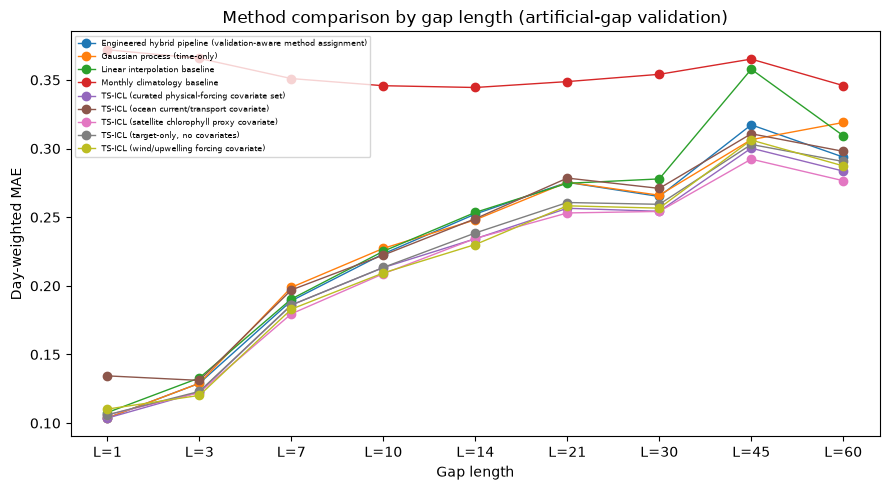

In [8]:
import matplotlib.pyplot as plt

length_order = sorted(pivot_length.index, key=lambda s: int(s.split("=")[1]))
fig, ax = plt.subplots(figsize=(9, 5))
for method in pivot_length.columns:
    ax.plot(length_order, pivot_length.loc[length_order, method], marker="o", label=method, lw=1)
ax.set_xlabel("Gap length")
ax.set_ylabel("Day-weighted MAE")
ax.legend(fontsize=6, loc="upper left")
ax.set_title("Method comparison by gap length (artificial-gap validation)")
plt.tight_layout()
plt.show()

## Part B.4 Performance by season

In [9]:
by_season = scores[scores["stratum_type"] == "season"]
by_season.pivot_table(index="stratum_value", columns="method_public_name", values="day_weighted_mae")

method_public_name,Engineered hybrid pipeline (validation-aware method assignment),Gaussian process (time-only),Linear interpolation baseline,Monthly climatology baseline,TS-ICL (curated physical-forcing covariate set),TS-ICL (ocean current/transport covariate),TS-ICL (satellite chlorophyll proxy covariate),"TS-ICL (target-only, no covariates)",TS-ICL (wind/upwelling forcing covariate)
stratum_value,,,,,,,,,
DJF,0.29780,0.29380,0.3045,0.4048,0.28780,0.3006,0.28170,0.2850,0.28260
JJA,0.19885,0.18875,0.2052,0.3000,0.17355,0.1996,0.16845,0.1805,0.18335
MAM,0.23790,0.26080,0.2490,0.3520,0.23920,0.2517,0.23710,0.2479,0.24240
SON,0.28860,0.28950,0.3058,0.3343,0.26760,0.2780,0.26610,0.2707,0.26540


## Part B.5 Event vs. non-event performance

In [10]:
event_perf = pd.read_csv("../results/chlorophyll/chlorophyll_event_performance_summary.csv")
event_perf[["method_public_name", "mae_event_days", "mae_nonevent_days", "event_penalty_mae_event_minus_nonevent"]]

,method_public_name,mae_event_days,mae_nonevent_days,event_penalty_mae_event_minus_nonevent
0,Linear interpolation baseline,0.3229,0.2295,0.0934
1,Monthly climatology baseline,0.3476,0.3546,-0.0070
2,Gaussian process (time-only),0.3158,0.2212,0.0945
3,Engineered hybrid pipeline (validation-aware m...,0.3087,0.2219,0.0868
4,Gap-edge residual model (deployed),0.2806,0.2046,0.0759
5,"TS-ICL (target-only, no covariates)",0.3010,0.2108,0.0902
6,TS-ICL (satellite chlorophyll proxy covariate),0.2916,0.2052,0.0864
7,TS-ICL (wind/upwelling forcing covariate),0.2998,0.2066,0.0932
8,TS-ICL (curated physical-forcing covariate set),0.2991,0.2058,0.0934
9,TS-ICL (ocean current/transport covariate),0.3136,0.2209,0.0927


## Part B.6 Covariate mechanism

Which covariates actually help, and which are merely correlated noise?
See `docs/methods.md` and the placebo-test rows below.

In [11]:
covariate_summary = pd.read_csv("../results/chlorophyll/chlorophyll_covariate_mechanism_summary.csv")
covariate_summary[covariate_summary["table_section"] == "covariate_arm_performance"][
    ["covariate_public_name", "n_gaps", "mae_mean", "rmse_mean", "bias_mean"]
].sort_values("mae_mean")

,covariate_public_name,n_gaps,mae_mean,rmse_mean,bias_mean
0,Solar x upwelling interaction,681,0.1981,0.2325,-0.0015
1,Upwelling x SST cooling interaction,681,0.1985,0.2336,-0.0060
2,Wind/upwelling forcing only,681,0.1985,0.2332,0.0063
3,Curated low-redundancy physical set,681,0.1988,0.2335,-0.0112
4,Satellite chlorophyll proxy + wind/upwelling,681,0.1993,0.2341,0.0092
5,Satellite chlorophyll proxy + availability proxy,681,0.1995,0.2345,-0.0030
6,Satellite chlorophyll proxy + solar,681,0.1997,0.2350,-0.0019
7,Satellite chlorophyll proxy + PLV meteorological,681,0.2010,0.2361,-0.0052
8,No covariate (target-only baseline),681,0.2014,0.2359,-0.0048
9,Solar radiation only,681,0.2015,0.2365,-0.0028


In [12]:
covariate_summary[covariate_summary["table_section"] == "placebo_robustness_test"]

,table_section,covariate_public_name,n_gaps,mae_mean,rmse_mean,bias_mean,evidence_note,comparison,context_mode,delta_mae_mean,delta_mae_ci_lo,delta_mae_ci_hi,significant
18,placebo_robustness_test,NaN,671,NaN,NaN,NaN,NaN,Curated physical-forcing covariate vs. randomi...,full_series,-0.00226,-0.00410,-0.00048,True
19,placebo_robustness_test,NaN,671,NaN,NaN,NaN,NaN,Curated physical-forcing covariate vs. randomi...,full_series,-0.00404,-0.00593,-0.00224,True
20,placebo_robustness_test,NaN,671,NaN,NaN,NaN,NaN,Curated physical-forcing covariate vs. randomi...,edge_balanced,-0.00178,-0.00336,-0.00025,True
21,placebo_robustness_test,NaN,671,NaN,NaN,NaN,NaN,Curated physical-forcing covariate vs. randomi...,edge_balanced,-0.00281,-0.00453,-0.00119,True


## Part B.7 Reproducing these numbers, not just loading them

Every table above is a frozen, already-released result -- this notebook
never re-runs a model. To regenerate the underlying TS-ICL predictions
yourself (requires `environments/tsicl/`, see `docs/reproducibility.md`):

```bash
PYTHONPATH=src environments/tsicl/.venv/bin/python -m experiments.chlorophyll.run_tsicl_benchmark \
    --support matched_449 --arms target_only,satellite_proxy \
    --context-modes full_series --out build/chlorophyll/tsicl_benchmark

PYTHONPATH=src environments/tsicl/.venv/bin/python -m experiments.chlorophyll.run_tsicl_covariate_analysis \
    --arms curated_physical,satellite_proxy --support matched_449 \
    --out build/chlorophyll/tsicl_covariates
```

Both drivers are restart-safe and checkpoint-verified
(`coastal_gap_reconstruction.tsicl_helpers.load_tsicl_strict` fails loudly
on any checkpoint/package mismatch rather than silently proceeding), and
write their own `RUN_STATUS`/`run_metadata.json` with full provenance --
they never overwrite the `results/` tables loaded above. Freshly generated
predictions are environment-sensitive (see `docs/reproducibility.md`);
compare them against the frozen tables using the evidence your own run
actually produces, not an assumed tolerance.